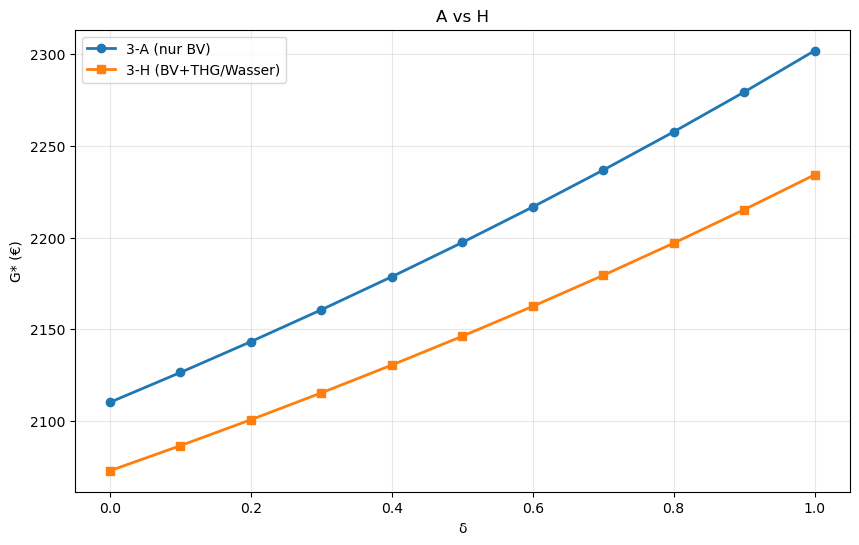

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import time
import matplotlib.pyplot as plt
import os

#Excel auslesen
excel_file = Path(r"C:\1Masterarbeit\Szenario_3\Inputdaten_8.xlsx")
input_folder = excel_file.parent
df = pd.read_excel(excel_file)

df_products = df.iloc[0:2, 1:4].copy()
df_products.columns = ['db_i', 'e_i', 'v_i']
df_products = df_products.astype(float)

df_b_fuzzy = df.iloc[3:5, 1:5].copy()
df_b_fuzzy.columns = ['b_u', 'b_o', 'gamma_i', 'beta_i']
df_b_fuzzy = df_b_fuzzy.astype(float)

df_scharfe = df.iloc[6:8, [0,1]].copy()
df_scharfe.columns = ['Parameter', 'Wert']
df_scharfe = df_scharfe.dropna()

df_bv_fuzzy = df.iloc[9:10, [0,1,2]].copy()
df_bv_fuzzy.columns = ['Parameter', 'BV_max', 'beta_BV']

gamma_BV = 0
n_produkte = len(df_products)
db, e, v = df_products['db_i'].values, df_products['e_i'].values, df_products['v_i'].values
b_u, b_o = df_b_fuzzy['b_u'].values, df_b_fuzzy['b_o'].values
gamma_i, beta_i = df_b_fuzzy['gamma_i'].values, df_b_fuzzy['beta_i'].values
E_max = float(df_scharfe[df_scharfe['Parameter']=='E_max']['Wert'])
W_max = float(df_scharfe[df_scharfe['Parameter']=='W_max']['Wert'])
BV_max = float(df_bv_fuzzy['BV_max'].iloc[0])
beta_BV = float(df_bv_fuzzy['beta_BV'].iloc[0])



def solve_scenario_gurobi(include_env=False, scenario_name="3"):
    results = []
    sensitivity = []
    
    deltas = np.arange(0, 1.1, 0.1)
    for delta in deltas:
       
        m = gp.Model(f"{scenario_name}_delta{delta}")
        m.Params.OutputFlag = 0 
        
        x = m.addVars(n_produkte, lb=0, name="x")
        #ZF
        m.setObjective(gp.quicksum(db[i] * x[i] for i in range(n_produkte)), GRB.MAXIMIZE)
        #NB Kern
        m.addConstr(gp.quicksum(b_o[i] * x[i] for i in range(n_produkte)) <= BV_max, "BV_Kern")
        #NB delta
        bv_rhs_delta = BV_max + beta_BV * (1 - delta)
        m.addConstr(
            gp.quicksum((b_o[i] + beta_i[i] * (1 - delta)) * x[i] for i in range(n_produkte)) <= bv_rhs_delta,
            "BV_delta"
        )
        
        # NB Umwelt
        if include_env:
            m.addConstr(gp.quicksum(e[i] * x[i] for i in range(n_produkte)) <= E_max, "THG")
            m.addConstr(gp.quicksum(v[i] * x[i] for i in range(n_produkte)) <= W_max, "Wasser")
        
        m.optimize()
        
        if m.Status == GRB.OPTIMAL:
            G = m.ObjVal
            x_vals = [x[i].X for i in range(n_produkte)]
          
            constraints_info = {}
            for c in m.getConstrs():
                c_name = c.ConstrName
                constraints_info[c_name] = {
                    'slack': c.Slack,
                    'shadow': c.Pi
                } 
        else:
            G, x_vals, constraints_info = np.nan, [np.nan] * n_prokte, {}
        
        results.append({
            'delta': delta, 'G': G, 
            **{f'x{i+1}': x_vals[i] for i in range(n_produkte)},
            'BV_delta_rhs': bv_rhs_delta, 'status': 'Optimal' if m.Status == GRB.OPTIMAL else 'Infeasible'
        })
        
        # SA
        sens_row = {'delta': delta}
        if m.Status == GRB.OPTIMAL:
            sens_row.update({
                'BV_Kern_slack': constraints_info['BV_Kern']['slack'],
                'BV_Kern_shadow': constraints_info['BV_Kern']['shadow'],
                'BV_delta_slack': constraints_info['BV_delta']['slack'],
                'BV_delta_shadow': constraints_info['BV_delta']['shadow']
            })
            if include_env:
                sens_row.update({
                    'THG_slack': constraints_info['THG']['slack'],
                    'THG_shadow': constraints_info['THG']['shadow'],
                    'Wasser_slack': constraints_info['Wasser']['slack'],
                    'Wasser_shadow': constraints_info['Wasser']['shadow']
                })
        sensitivity.append(sens_row)
    
    return pd.DataFrame(results), pd.DataFrame(sensitivity)

def run_sensitivity_3A_Coeff_Hybrid(delta_fixed):
    
    factors = [0.50, 0.75, 1.00, 1.25, 1.50]
    results_sa = []
    sensitivity_sa = []
    
    #beide delta simultan
    for beta_factor in factors:
        b_o_sa    = b_o.copy()
        beta_i_sa = [beta_i[i] * beta_factor for i in range(n_produkte)]
        
        G, x_vals, constraints_info, status = _solve_sa_case_3A(
            b_o_sa, beta_i_sa, delta_fixed, 
            f"3A_δ{delta_fixed}_A_beta{beta_factor:.2f}"
        )
        
        results_sa.append({
            'delta': delta_fixed, 'variant': 'Simultan', 'beta_factor': beta_factor,
            'G': G, **{f'x{i+1}': x_vals[i] for i in range(n_produkte)}, 'status': status
        })
        sensitivity_sa.append({
            'delta': delta_fixed, 'variant': 'Simultan', 'beta_factor': beta_factor,
            **_extract_sens_3A(constraints_info, status)
        })
    
    # delta nur für 1
    for beta_factor in factors:
        b_o_sa    = b_o.copy()
        beta_i_sa = [beta_i[0] * beta_factor, beta_i[1]]
        
        G, x_vals, constraints_info, status = _solve_sa_case_3A(
            b_o_sa, beta_i_sa, delta_fixed,
            f"3A_δ{delta_fixed}_B_Prod1_beta{beta_factor:.2f}"
        )
        
        results_sa.append({
            'delta': delta_fixed, 'variant': 'Prod1', 'beta_factor': beta_factor,
            'G': G, **{f'x{i+1}': x_vals[i] for i in range(n_produkte)}, 'status': status
        })
        sensitivity_sa.append({
            'delta': delta_fixed, 'variant': 'Prod1', 'beta_factor': beta_factor,
            **_extract_sens_3A(constraints_info, status)
        })
    
    # delta nur für 2
    for beta_factor in factors:
        b_o_sa    = b_o.copy()
        beta_i_sa = [beta_i[0], beta_i[1] * beta_factor]
        
        G, x_vals, constraints_info, status = _solve_sa_case_3A(
            b_o_sa, beta_i_sa, delta_fixed,
            f"3A_δ{delta_fixed}_C_Prod2_beta{beta_factor:.2f}"
        )
        
        results_sa.append({
            'delta': delta_fixed, 'variant': 'Prod2', 'beta_factor': beta_factor,
            'G': G, **{f'x{i+1}': x_vals[i] for i in range(n_produkte)}, 'status': status
        })
        sensitivity_sa.append({
            'delta': delta_fixed, 'variant': 'Prod2', 'beta_factor': beta_factor,
            **_extract_sens_3A(constraints_info, status)
        })
    
    return pd.DataFrame(results_sa), pd.DataFrame(sensitivity_sa)
def _solve_sa_case_3A(b_o_sa, beta_i_sa, delta_fixed, model_name):
    m = gp.Model(f"3A_SA_{model_name}")
    m.Params.OutputFlag = 0
    
    x = m.addVars(n_produkte, lb=0, name="x")
    m.setObjective(gp.quicksum(db[i] * x[i] for i in range(n_produkte)), GRB.MAXIMIZE)
    
    m.addConstr(gp.quicksum(b_o_sa[i] * x[i] for i in range(n_produkte)) <= BV_max, "BV_Kern")
    
    bv_rhs_delta = BV_max + beta_BV * (1 - delta_fixed)
    m.addConstr(
        gp.quicksum((b_o_sa[i] + beta_i_sa[i] * (1 - delta_fixed)) * x[i] 
                   for i in range(n_produkte)) <= bv_rhs_delta, "BV_delta"
    )
    
    
    m.optimize()
    
    if m.Status == GRB.OPTIMAL:
        G = m.ObjVal
        x_vals = [x[i].X for i in range(n_produkte)]
        constraints_info = {c.ConstrName: {'slack': c.Slack, 'shadow': c.Pi} for c in m.getConstrs()}
        status = 'Optimal'
        print(f"  ✓ 3A_{model_name}: G*={G:.1f}")
    else:
        G, x_vals, constraints_info, status = np.nan, [np.nan] * n_produkte, {}, 'Infeasible'
        print(f"  ✗ 3A_{model_name}: Infeasible")
    
    return G, x_vals, constraints_info, status

def _extract_sens_3A(constraints_info, status):
    sens = {}
    if status == 'Optimal':
        for cname in ['BV_Kern', 'BV_delta']: 
            if cname in constraints_info:
                sens[f"{cname}_slack"]  = constraints_info[cname]['slack']
                sens[f"{cname}_shadow"] = constraints_info[cname]['shadow']
    return sens

def run_sensitivity_3H_Coeff_Hybrid(delta_fixed):

    factors = [0.50, 0.75, 1.00, 1.25, 1.50]
    results_sa = []
    sensitivity_sa = []
    
  
    for beta_factor in factors:
        b_o_sa    = b_o.copy()  # FIX!
        beta_i_sa = [beta_i[i] * beta_factor for i in range(n_produkte)]
        
        G, x_vals, constraints_info, status = _solve_sa_case(
            b_o_sa, beta_i_sa, delta_fixed, 
            f"δ{delta_fixed}_A_beta{beta_factor:.2f}"
        )
        
        results_sa.append({
            'delta': delta_fixed, 'variant': 'Simultan', 'beta_factor': beta_factor,
            'G': G, **{f'x{i+1}': x_vals[i] for i in range(n_produkte)}, 'status': status
        })
        sensitivity_sa.append({
            'delta': delta_fixed, 'variant': 'Simultan', 'beta_factor': beta_factor,
            **_extract_sens(constraints_info, status)
        })
    
    for beta_factor in factors:
        b_o_sa    = b_o.copy()  # FIX!
        beta_i_sa = [beta_i[0] * beta_factor, beta_i[1]]  # Nur Prod1
        
        G, x_vals, constraints_info, status = _solve_sa_case(
            b_o_sa, beta_i_sa, delta_fixed,
            f"δ{delta_fixed}_B_Prod1_beta{beta_factor:.2f}"
        )
        
        results_sa.append({
            'delta': delta_fixed, 'variant': 'Prod1', 'beta_factor': beta_factor,
            'G': G, **{f'x{i+1}': x_vals[i] for i in range(n_produkte)}, 'status': status
        })
        sensitivity_sa.append({
            'delta': delta_fixed, 'variant': 'Prod1', 'beta_factor': beta_factor,
            **_extract_sens(constraints_info, status)
        })
    
    for beta_factor in factors:
        b_o_sa    = b_o.copy()  # FIX!
        beta_i_sa = [beta_i[0], beta_i[1] * beta_factor]  # Nur Prod2
        
        G, x_vals, constraints_info, status = _solve_sa_case(
            b_o_sa, beta_i_sa, delta_fixed,
            f"δ{delta_fixed}_C_Prod2_beta{beta_factor:.2f}"
        )
        
        results_sa.append({
            'delta': delta_fixed, 'variant': 'Prod2', 'beta_factor': beta_factor,
            'G': G, **{f'x{i+1}': x_vals[i] for i in range(n_produkte)}, 'status': status
        })
        sensitivity_sa.append({
            'delta': delta_fixed, 'variant': 'Prod2', 'beta_factor': beta_factor,
            **_extract_sens(constraints_info, status)
        })
    
    return pd.DataFrame(results_sa), pd.DataFrame(sensitivity_sa)

def _solve_sa_case(b_o_sa, beta_i_sa, delta_fixed, model_name):
    m = gp.Model(f"SA_{model_name}")
    m.Params.OutputFlag = 0
    
    x = m.addVars(n_produkte, lb=0, name="x")
    m.setObjective(gp.quicksum(db[i] * x[i] for i in range(n_produkte)), GRB.MAXIMIZE)
    
    m.addConstr(
        gp.quicksum(b_o_sa[i] * x[i] for i in range(n_produkte)) <= BV_max,
        "BV_Kern"
    )
    
    bv_rhs_delta = BV_max + beta_BV * (1 - delta_fixed)
    m.addConstr(
        gp.quicksum((b_o_sa[i] + beta_i_sa[i] * (1 - delta_fixed)) * x[i] for i in range(n_produkte)) <= bv_rhs_delta,
        "BV_delta"
    )
    
    m.addConstr(gp.quicksum(e[i] * x[i] for i in range(n_produkte)) <= E_max, "THG")
    m.addConstr(gp.quicksum(v[i] * x[i] for i in range(n_produkte)) <= W_max, "Wasser")
    
    m.optimize()
    
    if m.Status == GRB.OPTIMAL:
        G = m.ObjVal
        x_vals = [x[i].X for i in range(n_produkte)]
        constraints_info = {c.ConstrName: {'slack': c.Slack, 'shadow': c.Pi} for c in m.getConstrs()}
        status = 'Optimal'
        print(f"  ✓ {model_name}: G*={G:.1f}")
    else:
        G, x_vals, constraints_info, status = np.nan, [np.nan] * n_produkte, {}, 'Infeasible'
        print(f"  ✗ {model_name}: Infeasible")
    
    return G, x_vals, constraints_info, status

def _extract_sens(constraints_info, status):
    sens = {}
    if status == 'Optimal':
        for cname in ['BV_Kern', 'BV_delta', 'THG', 'Wasser']:
            if cname in constraints_info:
                sens[f"{cname}_slack"]  = constraints_info[cname]['slack']
                sens[f"{cname}_shadow"] = constraints_info[cname]['shadow']
    return sens

deltas_sa = [0.3, 0.5, 0.8]

df_sa_3A_all = pd.concat(df_sa_3A, ignore_index=True)
df_sa_sens_3A_all = pd.concat(df_sa_sens_3A, ignore_index=True)

df_sa_3H_all = pd.concat(df_sa_3H, ignore_index=True)
df_sa_sens_3H_all = pd.concat(df_sa_sens_3H, ignore_index=True)


#Excel SA
output_file_complete = input_folder / "SA_Komplett_3A_3H.xlsx"
with pd.ExcelWriter(output_file_complete, engine='openpyxl') as writer:
    
    for i, delta in enumerate(deltas_sa):
        df_sa_3A[i].to_excel(writer, sheet_name=f'3A_d{int(delta*10)}', index=False)
        df_sa_sens_3A[i].to_excel(writer, sheet_name=f'3A_d{int(delta*10)}_Sens', index=False)
    
    for i, delta in enumerate(deltas_sa):
        df_sa_3H[i].to_excel(writer, sheet_name=f'3H_d{int(delta*10)}', index=False)  
        df_sa_sens_3H[i].to_excel(writer, sheet_name=f'3H_d{int(delta*10)}_Sens', index=False)
    
df_results_A, df_sens_A = solve_scenario_gurobi(include_env=False, scenario_name="3A")
df_results_H, df_sens_H = solve_scenario_gurobi(include_env=True, scenario_name="3H")

# Excel Export
output_file = input_folder / "Szenario3_Ergebnisse.xlsx"
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    df_results_A.to_excel(writer, sheet_name='3A', index=False)
    df_sens_A.to_excel(writer, sheet_name='3A_Sens', index=False)
    df_results_H.to_excel(writer, sheet_name='3H', index=False)
    df_sens_H.to_excel(writer, sheet_name='3H_Sens', index=False)


# Grafik
plt.figure(figsize=(10,6))
plt.plot(df_results_A['delta'], df_results_A['G'], 'o-', label='3-A (nur BV)', linewidth=2)
plt.plot(df_results_H['delta'], df_results_H['G'], 's-', label='3-H (BV+THG/Wasser)', linewidth=2)
plt.xlabel('δ'); plt.ylabel('G* (€)'); plt.title('A vs H')
plt.legend(); plt.grid(True, alpha=0.3)
plt.savefig(input_folder / "Szenario3_A_H_Gurobi.png", dpi=300, bbox_inches='tight')
plt.show()

